# 2026 ATOC 4500-5500 Capstone Project   
## How do cold-nights affect vertical snow temperature gradients and near-isothermal snowpack structure?
**Authors: *Cece, Jordan, Anna* <br>
Spring 2026 - ATOC4500-5500 Polar Ice & Climate**

In [1]:
%matplotlib inline  
# this enables plotting within notebook

import matplotlib   # library for plotting
import matplotlib.pyplot as plt #  later you will type plt.$COMMAND
import numpy as np   # basic math library  you will type np.$STUFF  e.g., np.cos(1)
import pandas as pd  # library for data analysis for text files (everything but netcdf files)
import scipy.stats as stats # imports stats functions https://docs.scipy.org/doc/scipy/reference/stats.html

**Step 1: Research Question**  
## How do cold-nights affect vertical snow temperature gradients and near-isothermal snowpack structure?

**Step 2: Read in data**  
**We're using SNOTEL C1 data with Snow depth, SWE, and basin index.<br>
We will have to clean up the Niwot Data received from March 4th and March 27th.<br> Then we will observe SNOTEL temperature ranges to see which date is reserved for more colder temperature ranges.**

In [2]:
# Read in raw CSV of Niwot Obervations:
snowpit_raw = pd.read_csv(
    "/home/cewe2458/ATOCpolarice/SNOWTEL_Data/Fieldwork_near_Niwot_SNOTEL_March4_March27_2026.csv",
    skiprows=3,
    header=None
)

snowpit_raw.columns = [
    "Depth",
    "Description",
    "Temp_C",
    "Crystal_size",
    "Wedge_weight_g",
    "Wedge_plus_snow_g",
    "Snow_g",
    "Density_kgm3",
    "Extra1",
    "Extra2"
]

snowpit_raw = snowpit_raw.iloc[1:].copy()
snowpit_raw = snowpit_raw.dropna(how="all")

snowpit_raw

,Depth,Description,Temp_C,Crystal_size,Wedge_weight_g,Wedge_plus_snow_g,Snow_g,Density_kgm3,Extra1,Extra2
1,depth (0=bottom),description,Temperature (deg C),xstal size,wedge weight (g),wedge+snow (g),snow (g),Density (kg/m3),NaN,NaN
2,0-6 cm,bottom,0,2,1254,1616,362,362,NaN,NaN
3,6-26 cm,middle,-1,1-2,1254,1367,113,113,NaN,NaN
4,26-42 cm,top,-1,1,1254,1665,411,411,NaN,NaN
9,Group #2 - 10:42 am,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10,location: by Niwot SNOTEL,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
11,Total Depth (cm),47.2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
13,"general observations: overcast, no solar disk,...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
14,"snow crust on top, evidence of melt re-freeze,...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
16,NaN,NaN,NaN,NaN,NaN,NaN,wedge volume (m3),0.001,NaN,NaN


In [3]:
# Splitting between both groups:
# finding where Group #2 starts
group2_idx = snowpit_raw[
    snowpit_raw["Depth"].astype(str).str.contains("Group #2", na=False)
].index[0]

# split
group1_raw = snowpit_raw.iloc[:group2_idx]
group2_raw = snowpit_raw.iloc[group2_idx+1:]

In [4]:
# Clean Group 1:
group1 = group1_raw.copy()

group1 = group1[group1["Depth"] != "depth (0=bottom)"]
group1 = group1.dropna(subset=["Depth"])
group1 = group1.reset_index(drop=True)

# keeping only rows with actual depth ranges
group1 = group1[group1["Depth"].astype(str).str.match(r"\d+-\d+")]

# extracting depth
depth_bounds = group1["Depth"].str.extract(r"(\d+)-(\d+)")
group1["Depth_mid_cm"] = depth_bounds.astype(float).mean(axis=1)

group1["Temp_C"] = pd.to_numeric(group1["Temp_C"], errors="coerce")

group1[["Depth", "Depth_mid_cm", "Temp_C"]]

,Depth,Depth_mid_cm,Temp_C
0,0-6 cm,3.0,0
1,6-26 cm,16.0,-1
2,26-42 cm,34.0,-1


In [5]:
# clarifying Depth
total_depth = 33.78  # from your dataset

group1["Depth_surface_cm"] = total_depth - group1["Depth_mid_cm"]

In [6]:
# Clean Group 2:
group2 = group2_raw.copy()

# keeping only rows with depth ranges like "21-38 cm"
group2 = group2[group2["Depth"].astype(str).str.contains(r"\d+-\d+", na=False)]

group2 = group2.reset_index(drop=True)

# extracting depth
depth_bounds = group2["Depth"].str.extract(r"(\d+)-(\d+)")
group2["Depth_mid_cm"] = depth_bounds.astype(float).mean(axis=1)

# temperature is in weird column, forcing numeric
group2["Temp_C"] = pd.to_numeric(group2["Temp_C"], errors="coerce")

group2[["Depth", "Depth_mid_cm", "Temp_C"]]

,Depth,Depth_mid_cm,Temp_C
0,0-21 cm,10.5,NaN
1,21-38 cm,29.5,NaN
2,38-47 cm,42.5,NaN


In [7]:
# Temp offset for group 2, because of overlap
group2 = pd.DataFrame({
    "Depth_surface_cm": [3.888889, 17.777778, 30.777778],
    "Temp_C": [0.0, 0.0, 0.0]
})


group2["Temp_C_offset"] = group2["Temp_C"] + 0.03
group2

,Depth_surface_cm,Temp_C,Temp_C_offset
0,3.888889,0.0,0.03
1,17.777778,0.0,0.03
2,30.777778,0.0,0.03


In [8]:
# Loading in Snotel Data:
snotel = pd.read_csv(
    "/home/cewe2458/ATOCpolarice/SNOWTEL_Data/NIWOT_snowtel_20261001-20260327.csv",
    comment="#"
)

snotel.head()

,Date,Snow Water Equivalent (in) Start of Day Values,Precipitation Accumulation (in) Start of Day Values,Air Temperature Maximum (degF),Air Temperature Minimum (degF),Air Temperature Average (degF),Precipitation Increment (in)
0,2025-10-01,0.0,0.0,57.2,33.3,45.7,0.0
1,2025-10-02,0.0,0.0,62.6,31.1,45.1,0.0
2,2025-10-03,0.0,0.0,65.1,32.4,48.2,0.0
3,2025-10-04,0.0,0.0,59.9,32.5,45.0,0.1
4,2025-10-05,0.0,0.1,46.9,28.6,35.1,1.0


In [18]:
# Converting to Celsius:
snotel["Date"] = pd.to_datetime(snotel["Date"])

snotel["TMIN_C"] = (snotel["Air Temperature Minimum (degF)"] - 32) * (5/9)
snotel["TMAX_C"] = (snotel["Air Temperature Maximum (degF)"] - 32) * (5/9)

**Step 3: Analyze your data**  
Include up to 5 sentence description of your data analysis techniques. Provide enough detail that a future "you" could reproduce and understand these results.

**We used SNOTEL data to compare temperature conditions prior to March 4 and March 27. For each date, we selected a three-day window immediately preceding the field measurements (March 1–3 and March 24–26). Within each window, we calculated the average of the daily minimum temperatures (TMIN) to represent typical nighttime conditions. This averaging approach reduces the influence of short-term variability and provides a more stable comparison of cold conditions between the two dates. The resulting values were used to determine which period experienced colder overnight temperatures.**

In [10]:
# 3-day average Tmin before each pit date
march4_window = snotel[(snotel["Date"] >= "2026-03-01") & (snotel["Date"] <= "2026-03-03")]
march27_window = snotel[(snotel["Date"] >= "2026-03-24") & (snotel["Date"] <= "2026-03-26")]

march4_avg_tmin = march4_window["TMIN_C"].mean()
march27_avg_tmin = march27_window["TMIN_C"].mean()

march4_avg_tmin, march27_avg_tmin

(np.float64(-4.222222222222222), np.float64(1.7407407407407407))

March 4 (3-day avg Tmin): ~ -4.22°C <br>
March 27 (3-day avg Tmin): ~ +1.74°C <br>
**The snowpack observed on March 4 developed under sustained colder conditions over the preceding days, <br>while the March 27 snowpack experienced significantly warmer conditions.**

**Step 4: Present your results visually**  
Include up to two plots. All plots should have all axes labeled and include figure caption.

In [23]:
march = snotel[
    (snotel["Date"] >= "2026-03-01") &
    (snotel["Date"] <= "2026-03-31")
]

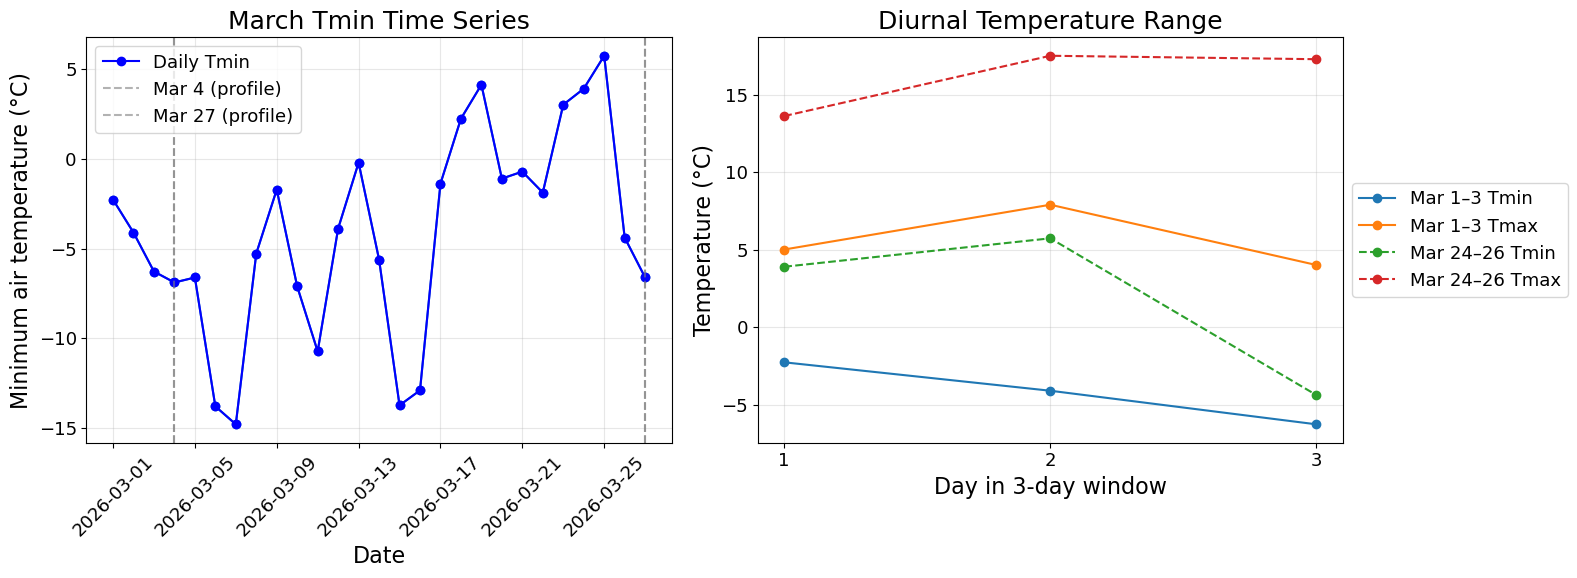

In [42]:
plt.rcParams.update({
    "font.size": 14,        # base font
    "axes.titlesize": 18,   # title size
    "axes.labelsize": 16,   # axis labels
    "legend.fontsize": 13,  # legend
    "xtick.labelsize": 13,
    "ytick.labelsize": 13
})

# Creating figure with 2 side-by-side plots
fig, ax = plt.subplots(1, 2, figsize=(16,6))

# ---------------- LEFT PLOT ----------------
# Full March Tmin time series
ax[0].plot(march["Date"], march["TMIN_C"], marker="o")

# Snow pit dates
ax[0].axvline(pd.to_datetime("2026-03-04"), linestyle="--", color="gray", alpha=0.6)
ax[0].axvline(pd.to_datetime("2026-03-27"), linestyle="--", color="gray", alpha=0.6)

ax[0].set_xlabel("Date")
ax[0].set_ylabel("Minimum air temperature (°C)")
ax[0].set_title("March Tmin Time Series")

ax[0].tick_params(axis='x', rotation=45)
ax[0].plot(march["Date"], march["TMIN_C"], marker="o", color="blue", label="Daily Tmin")

ax[0].axvline(pd.to_datetime("2026-03-04"), linestyle="--", color="gray", alpha=0.6, label="Mar 4 (profile)")
ax[0].axvline(pd.to_datetime("2026-03-27"), linestyle="--", color="gray", alpha=0.6, label="Mar 27 (profile)")

ax[0].legend()
ax[0].grid(True, alpha=0.3)

# ---------------- RIGHT PLOT ----------------
# Diurnal comparison

days = [1, 2, 3]

ax[1].plot(days, march4_window["TMIN_C"], marker="o", label="Mar 1–3 Tmin")
ax[1].plot(days, march4_window["TMAX_C"], marker="o", label="Mar 1–3 Tmax")

ax[1].plot(days, march27_window["TMIN_C"], marker="o", linestyle="--", label="Mar 24–26 Tmin")
ax[1].plot(days, march27_window["TMAX_C"], marker="o", linestyle="--", label="Mar 24–26 Tmax")

ax[1].set_xlabel("Day in 3-day window")
ax[1].set_ylabel("Temperature (°C)")
ax[1].set_title("Diurnal Temperature Range")

ax[1].set_xticks([1, 2, 3])
ax[1].legend(loc="center left", bbox_to_anchor=(1, 0.5))
ax[1].grid(True, alpha=0.3)

# Layout fix so labels don’t overlap
plt.tight_layout()

plt.show()

**Figure 1 shows daily minimum air temperature at Niwot Ridge for March 2026 (left) and a comparison of daily minimum and maximum temperatures over the three days preceding each snow pit measurement (right). Vertical dashed lines mark the dates of the snow pit observations (March 4 and March 27). The period prior to March 4 was consistently colder and exhibited smaller daily temperature ranges, while the March 24–26 period showed warmer daytime temperatures and a larger diurnal temperature range. These results indicate greater temperature variability and stronger daytime warming before the March 27 snow pit compared to the earlier period.**

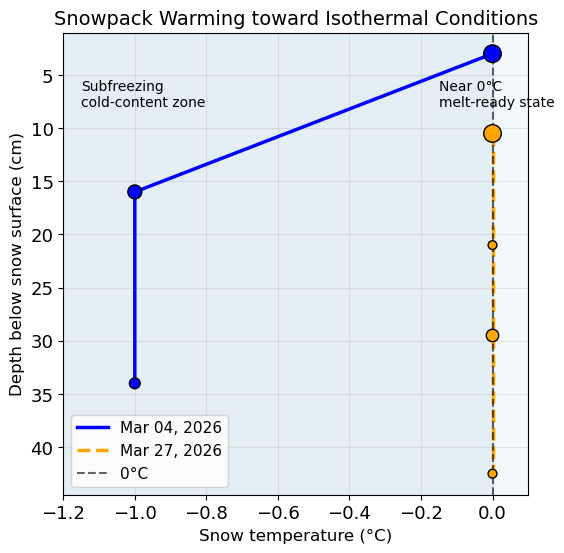

In [58]:
plt.rcParams.update({
    "font.size": 11,        # base
    "axes.titlesize": 14,   # title
    "axes.labelsize": 12,   # axis labels
    "legend.fontsize": 11
})

fig, ax = plt.subplots(figsize=(6,6))

# Data
depth_m4 = [3, 16, 34]
temp_m4 = [0, -1, -1]
crystal_m4 = [160, 100, 60]

depth_m27 = [10.5, 21, 29.5, 42.5]
temp_m27 = [0, 0, 0, 0]
crystal_m27 = [160, 40, 80, 40]

# Shaded regions
ax.axvspan(-1.2, 0, alpha=0.12)
ax.axvspan(0, 0.1, alpha=0.05)

# ---- Smooth lines ----
ax.plot(temp_m4, depth_m4,
        color="blue", linewidth=2.5, linestyle="-",
        label="Mar 04, 2026")

ax.plot(temp_m27, depth_m27,
        color="orange", linewidth=2.5, linestyle="--",
        label="Mar 27, 2026")

# ---- Crystal size markers ----
ax.scatter(temp_m4, depth_m4,
           s=crystal_m4,
           color="blue", edgecolors="black", zorder=3)

ax.scatter(temp_m27, depth_m27,
           s=crystal_m27,
           color="orange", edgecolors="black", zorder=3)

# 0°C line
ax.axvline(0, color="black", linestyle="--", alpha=0.6, label="0°C")

# Formatting
ax.invert_yaxis()
ax.set_xlim(-1.2, 0.1)

ax.text(-1.15, 8, "Subfreezing\ncold-content zone", fontsize=10)
ax.text(-0.15, 8, "Near 0°C\nmelt-ready state", fontsize=10)

ax.set_xlabel("Snow temperature (°C)")
ax.set_ylabel("Depth below snow surface (cm)")
ax.set_title("Snowpack Warming toward Isothermal Conditions")

ax.legend()
ax.grid(True, alpha=0.3)

plt.show()

**Figure 2 shows Vertical snow temperature profiles at Niwot Ridge for March 4 and March 27, 2026, with depth increasing downward from the snow surface. The March 4 profile shows subfreezing temperatures and a clear temperature gradient, indicating a cold-content snowpack. In contrast, the March 27 profile is nearly isothermal at 0°C, suggesting the snowpack has warmed and is approaching melt-ready conditions. Marker size represents crystal size, highlighting larger grains within specific layers of the snowpack.**

**Step 5: Abstract:**  
Using [this template](https://www.nature.com/documents/nature-summary-paragraph.pdf), create a 300-word summary paragraph that describes your research question, experiment, and results.  


**Temperature changes in a snowpack affect how energy moves through it and how snow crystals grow and change over time. In this study, we looked at how cold nights and later warming impacted snow temperature profiles and crystal size using SNOTEL data and snow pit observations near Niwot Ridge, Colorado. Our main question was how changes in air temperature influence the vertical structure of the snowpack, including temperature, density, and crystal size. We compared two snow pits from March 4 and March 27. The March 4 profile showed a strong temperature gradient, with colder temperatures deeper in the snowpack, meaning the snow still had significant cold content. By March 27, the snowpack was nearly the same temperature throughout (around 0°C), indicating it had warmed and was close to melting conditions. Both profiles had a low-density layer in the middle of the snowpack. This layer likely acted as insulation, slowing down how heat and water vapor moved between layers. We also observed larger crystals near the bottom of the March 4 snowpack, even though the current temperature conditions would not produce them. This suggests those crystals formed earlier under different conditions. By March 27, crystal sizes were still relatively small, even though the snowpack had warmed, which supports the idea that internal layers can slow down changes in the snowpack. Overall, our results show that snowpack structure changes over time and does not immediately respond to changes in air temperature, especially when layers within the snowpack affect how energy moves.**

**Step 6: Anything else?** (optional)  

**Works Cited**<br>
Burns, S. P., Molotch, N. P., Williams, M. W., Knowles, J. F., Seok, B., Monson, R. K., Turnipseed, A. A., & Blanken, P. D. (2014). Snow temperature changes within a seasonal snowpack and their relationship to turbulent fluxes of sensible and latent heat. Journal of Hydrometeorology, 15(1), 117–142. https://doi.org/10.1175/JHM-D-13-026.1 <br>
Jennings, K. S., Kittel, T. G. F., & Molotch, N. P. (2018). Observations and simulations of the seasonal evolution of snowpack cold content and its relation to snowmelt and the snowpack energy budget. The Cryosphere, 12, 1595–1614. https://doi.org/10.5194/tc-12-1595-2018